# Predicting Bottom Dissolved Oxygen from Surface Variables

In this module, we build a complete machine learning workflow using real environmental data.

We demonstrate how to predict bottom dissolved oxygen (DO) using surface water quality variables from the Chesapeake Bay Program (CBP) DataHub, including:

* Chlorophyll-a
* Salinity
* Nutrients (TN, TP)
* Water temperature (WTEMP)

The raw data used in this tutorial can be downloaded from:
https://datahub.chesapeakebay.net/WaterQuality

We use data from three mainstem stations across the Chesapeake Bay (1984–2024):

* Upper Bay: CB3.2
* Middle Bay: CB5.1
* Lower Bay: CB6.4


We will follow a complete workflow:

Raw Data → Clean Data → Train Model → Predict



## Learning Objectives

* Prepare raw water quality data for machine learning
* Build and evaluate predictive models (Random Forest and MLP)
* Understand how input variables influence model predictions
* Apply trained models to new datasets for DO prediction
* Compare model performance and interpret results


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!git clone https://github.com/CGC-UMCES/NAIRR-2026-Tutorial-Intro-ML-Predict-DO.git /content/NAIRR-2026-Tutorial-Intro-ML-Predict-DO

Cloning into '/content/NAIRR-2026-Tutorial-Intro-ML-Predict-DO'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 36 (delta 11), reused 16 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 10.94 MiB | 17.70 MiB/s, done.
Resolving deltas: 100% (11/11), done.


####<font color="#FF69B4">Set the working directory to /content/NAIRR-2026-Tutorial-Intro-ML-Predict-DO

In [2]:
import os

working_directory = '/content/NAIRR-2026-Tutorial-Intro-ML-Predict-DO'
os.chdir(working_directory)
print(f"Working directory set to: {os.getcwd()}")

Working directory set to: /content/NAIRR-2026-Tutorial-Intro-ML-Predict-DO


## Section 1: Data Cleaning and Preparation

### What You Will Do

* Load and explore raw data
* Handle missing values and duplicates
* Filter and organize variables
* Create a model-ready dataset

### Key Idea

Clean and consistent data is essential for building reliable models.


####<font color="#FF69B4">Display the image: map_of_mainstem_and_tributary_monitoring_stations.png

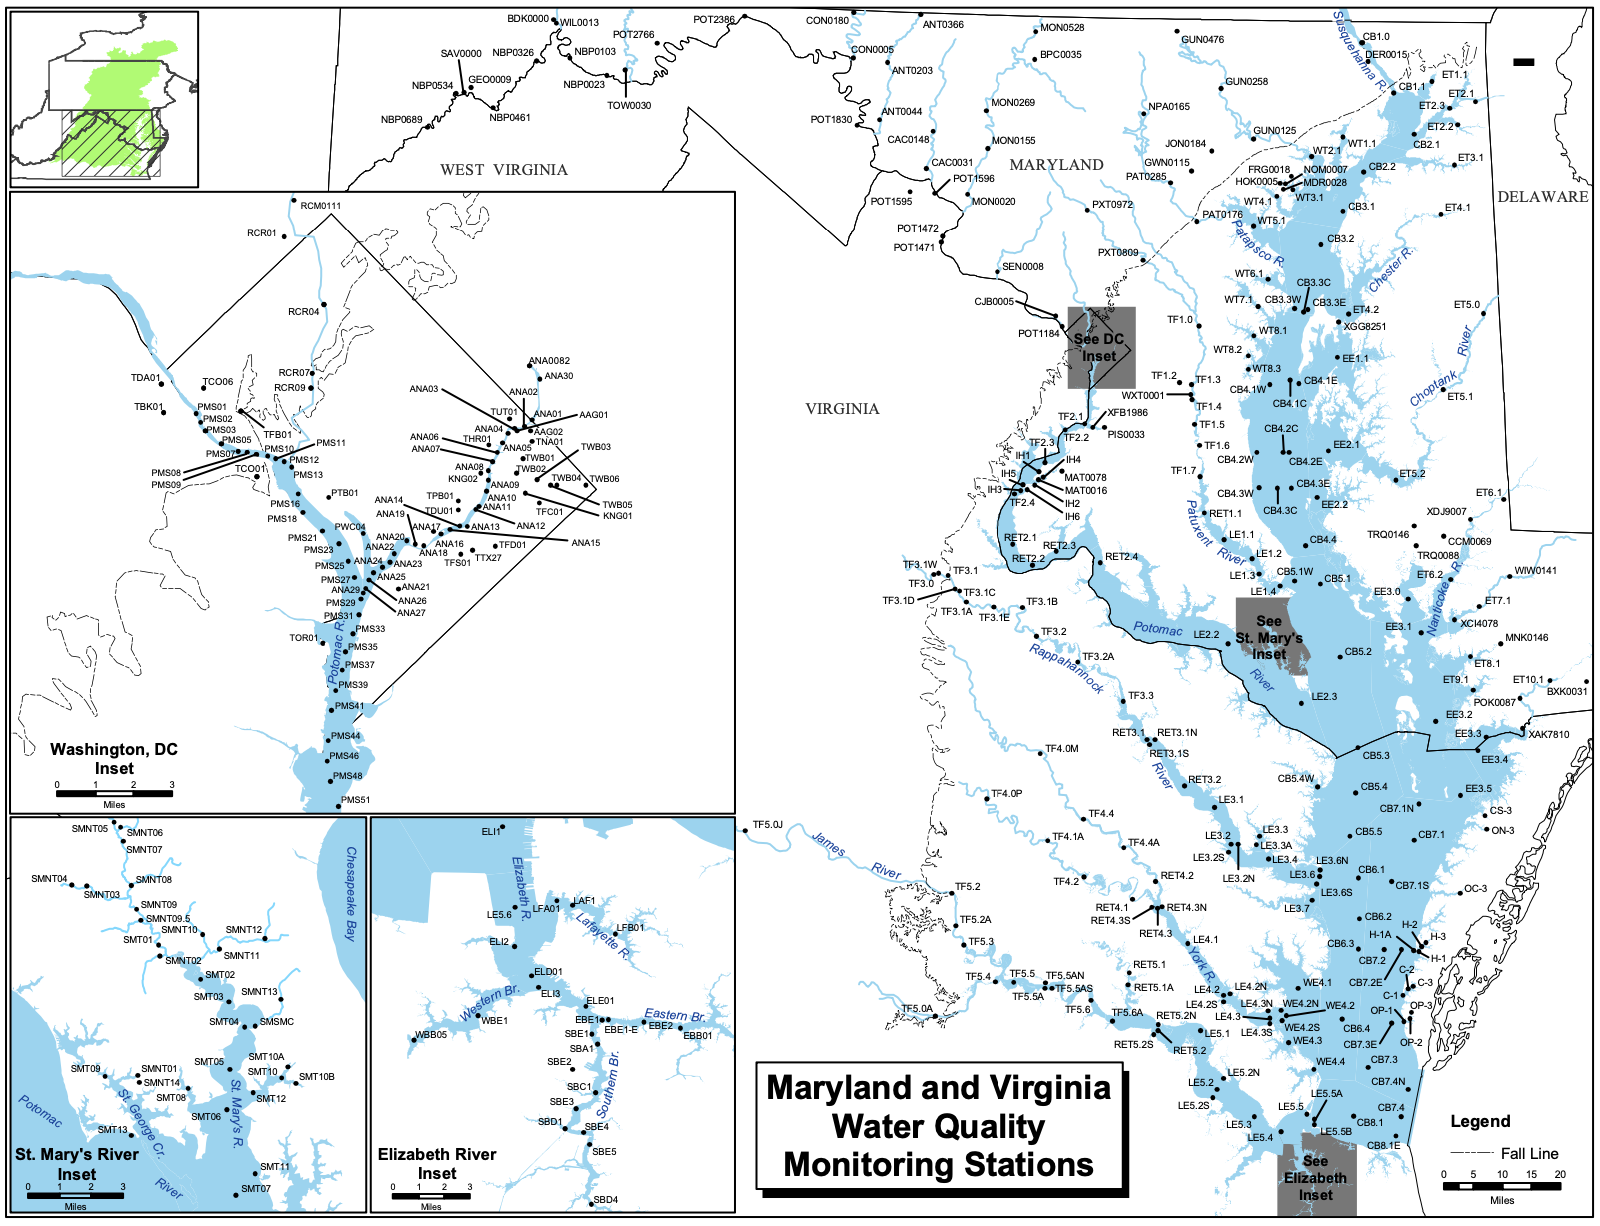

In [ ]:
from IPython.display import Image
Image('map_of_mainstem_and_tributary_monitoring_stations.png')

####<font color="#FF69B4">Read the file "CBP_RawData/Upper_StationCB3.2.csv" using pandas and store it in df.

In [ ]:
import pandas as pd
df = pd.read_csv('CBP_RawData/Upper_StationCB3.2.csv')
print("DataFrame df created successfully.")
df.head()

DataFrame df created successfully.


,MonitoringStation,EventId,SampleDate,Layer,Parameter,MeasureValue,Unit
0,CB3.2,126589,7/12/84,B,CHLA,4.0,UG/L
1,CB3.2,126589,7/12/84,S,CHLA,2.7,UG/L
2,CB3.2,126589,7/12/84,BP,CHLA,1.3,UG/L
3,CB3.2,126707,7/25/84,AP,CHLA,5.3,UG/L
4,CB3.2,126707,7/25/84,B,CHLA,5.3,UG/L


####<font color="#FF69B4">Display how many rows in the df.

In [ ]:
print(f"Total number of rows in df: {df.shape[0]}")

Total number of rows in df: 30561


####<font color="#FF69B4">Show, for each column in df: the value range, the number of unique values, and up to 10 example unique values

In [ ]:
import pandas as pd

for col in df.columns:
    print(f"\n--- Column: {col} ---")

    # Number of unique values
    unique_count = df[col].nunique()
    print(f"Unique values count: {unique_count}")

    # Display up to 10 unique values
    unique_values_sample = df[col].unique()
    if unique_count > 10:
        print(f"Sample of unique values (first 10): {unique_values_sample[:10].tolist()}")
    else:
        print(f"All unique values: {unique_values_sample.tolist()}")

    # Value Range for numeric and datetime columns
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"Value Range (Min, Max): ({df[col].min()}, {df[col].max()})")
    elif pd.api.types.is_datetime64_any_dtype(df[col]):
        print(f"Value Range (Min, Max): ({df[col].min().strftime('%Y-%m-%d')}, {df[col].max().strftime('%Y-%m-%d')})")
    else:
        print("Value Range: N/A (non-numeric/non-datetime type)")


--- Column: MonitoringStation ---
Unique values count: 1
All unique values: ['CB3.2']
Value Range: N/A (non-numeric/non-datetime type)

--- Column: EventId ---
Unique values count: 667
Sample of unique values (first 10): [126589, 126707, 126820, 126931, 127400, 127162, 127033, 127292, 127456, 127807]
Value Range (Min, Max): (39, 691267)

--- Column: SampleDate ---
Unique values count: 667
Sample of unique values (first 10): ['7/12/84', '7/25/84', '8/7/84', '8/30/84', '10/24/84', '9/26/84', '9/12/84', '10/10/84', '11/7/84', '2/13/85']
Value Range: N/A (non-numeric/non-datetime type)

--- Column: Layer ---
Unique values count: 5
All unique values: ['B ', 'S ', 'BP', 'AP', 'M ']
Value Range: N/A (non-numeric/non-datetime type)

--- Column: Parameter ---
Unique values count: 6
All unique values: ['CHLA', 'DO', 'SALINITY', 'TN', 'TP', 'WTEMP']
Value Range: N/A (non-numeric/non-datetime type)

--- Column: MeasureValue ---
Unique values count: 3569
Sample of unique values (first 10): [4.0, 2

####<font color="#FF69B4">Check for NaN values and display the rows that contain NaN in the df.

In [ ]:
print("Checking for missing values (NaN) in df:")
missing_values_rows = df[df.isnull().any(axis=1)]

if missing_values_rows.empty:
    print("No missing values found in df.")
else:
    print(f"Found {len(missing_values_rows)} rows with missing values in df:")
    print(missing_values_rows.to_string())

Checking for missing values (NaN) in df:
Found 30 rows with missing values in df:
      MonitoringStation  EventId SampleDate Layer Parameter  MeasureValue  Unit
217               CB3.2   131992    5/29/08    BP      CHLA           NaN  UG/L
346               CB3.2   416754    1/28/16    AP      CHLA           NaN  UG/L
873               CB3.2   487677   12/23/20    S       CHLA           NaN  UG/L
1507              CB3.2    68363    3/16/11    AP      CHLA           NaN  UG/L
1940              CB3.2    33551    1/12/05    AP      CHLA           NaN  UG/L
2172              CB3.2   105269    6/17/09    B       CHLA           NaN  UG/L
4562              CB3.2   444747    9/27/17    S         DO           NaN  MG/L
4563              CB3.2   444747    9/27/17    M         DO           NaN  MG/L
4564              CB3.2   444747    9/27/17    M         DO           NaN  MG/L
4573              CB3.2   444747    9/27/17    AP        DO           NaN  MG/L
4577              CB3.2   444747    9/

####<font color="#FF69B4">Remove all rows containing NaN values from df, save the result as df_clean_NaN, and display it.

In [ ]:
print(f"Original number of rows in df: {df.shape[0]}")
df_clean_NaN = df.dropna()
print(f"Number of rows in df_clean_NaN after removing NaNs: {df_clean_NaN.shape[0]}")
print("First 5 rows of df_clean_NaN:")
print(df_clean_NaN.head().to_string())

Original number of rows in df: 30561
Number of rows in df_clean_NaN after removing NaNs: 30531
First 5 rows of df_clean_NaN:
  MonitoringStation  EventId SampleDate Layer Parameter  MeasureValue  Unit
0             CB3.2   126589    7/12/84    B       CHLA           4.0  UG/L
1             CB3.2   126589    7/12/84    S       CHLA           2.7  UG/L
2             CB3.2   126589    7/12/84    BP      CHLA           1.3  UG/L
3             CB3.2   126707    7/25/84    AP      CHLA           5.3  UG/L
4             CB3.2   126707    7/25/84    B       CHLA           5.3  UG/L


####<font color="#FF69B4">Convert the "SampleDate" column in df_clean_NaN to datetime format, and display it.

In [ ]:
import pandas as pd
df_clean_NaN['SampleDate'] = pd.to_datetime(df_clean_NaN['SampleDate'])
print("'SampleDate' column in df_clean_NaN converted to datetime format.")
print(df_clean_NaN['SampleDate'].head())

'SampleDate' column in df_clean_NaN converted to datetime format.
0   1984-07-12
1   1984-07-12
2   1984-07-12
3   1984-07-25
4   1984-07-25
Name: SampleDate, dtype: datetime64[ns]


/tmp/ipykernel_3501/2613077186.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean_NaN['SampleDate'] = pd.to_datetime(df_clean_NaN['SampleDate'])
/tmp/ipykernel_3501/2613077186.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_NaN['SampleDate'] = pd.to_datetime(df_clean_NaN['SampleDate'])


####<font color="#FF69B4">Randomly select one date and display the rows from that date in df_clean_NaN.

In [ ]:
import numpy as np
import pandas as pd

# Ensure 'SampleDate' is datetime type
if not pd.api.types.is_datetime64_any_dtype(df_clean_NaN['SampleDate']):
    df_clean_NaN['SampleDate'] = pd.to_datetime(df_clean_NaN['SampleDate'])

# Randomly select one unique date from the 'SampleDate' column
random_date_np = np.random.choice(df_clean_NaN['SampleDate'].unique())

# Convert the numpy.datetime64 to pandas Timestamp for easier comparison
random_date_pd = pd.Timestamp(random_date_np)

print(f"Randomly chosen date: {random_date_pd.strftime('%Y-%m-%d')}")

# Filter the DataFrame to display rows for the chosen date
df_random_date = df_clean_NaN[df_clean_NaN['SampleDate'] == random_date_pd]
print(df_random_date.to_string())

Randomly chosen date: 2003-05-07
      MonitoringStation  EventId SampleDate Layer Parameter  MeasureValue   Unit
1559              CB3.2    73154 2003-05-07    S       CHLA        4.1120   UG/L
1560              CB3.2    73154 2003-05-07    AP      CHLA        2.9900   UG/L
1561              CB3.2    73154 2003-05-07    BP      CHLA        3.7380   UG/L
1562              CB3.2    73154 2003-05-07    B       CHLA        3.7380   UG/L
6954              CB3.2    73154 2003-05-07    M         DO        1.9000   MG/L
6956              CB3.2    73154 2003-05-07    B         DO        2.1000   MG/L
6957              CB3.2    73154 2003-05-07    M         DO        2.6000   MG/L
6958              CB3.2    73154 2003-05-07    M         DO        2.2000   MG/L
6959              CB3.2    73154 2003-05-07    BP        DO        3.3000   MG/L
6960              CB3.2    73154 2003-05-07    M         DO        6.0000   MG/L
6961              CB3.2    73154 2003-05-07    M         DO        3.9000   

####<font color="#FF69B4">Check if there are  duplicate measurements in df_clean_NaN

In [ ]:
print("Checking for duplicate measurements (same MonitoringStation, SampleDate, Layer, and Parameter) in `df_clean_NaN`:")
duplicate_check_cols = ['MonitoringStation', 'SampleDate', 'Layer', 'Parameter']
duplicates_in_df_clean_NaN = df_clean_NaN[df_clean_NaN.duplicated(subset=duplicate_check_cols, keep=False)]

if not duplicates_in_df_clean_NaN.empty:
    print(f"Found {len(duplicates_in_df_clean_NaN)} rows in `df_clean_NaN` that have duplicate measurements for the same station, date, layer, and parameter combination.")
    print("Here are the first 10 entries of these duplicates:")
    print(duplicates_in_df_clean_NaN.sort_values(by=duplicate_check_cols).head(10).to_string())
else:
    print("No duplicate measurements found in `df_clean_NaN` for the same station, date, layer, and parameter combination.")

Checking for duplicate measurements (same MonitoringStation, SampleDate, Layer, and Parameter) in `df_clean_NaN`:
Found 15348 rows in `df_clean_NaN` that have duplicate measurements for the same station, date, layer, and parameter combination.
Here are the first 10 entries of these duplicates:
     MonitoringStation  EventId SampleDate Layer Parameter  MeasureValue  Unit
3061             CB3.2   126589 1984-07-12    M         DO           4.3  MG/L
3062             CB3.2   126589 1984-07-12    M         DO           3.6  MG/L
3064             CB3.2   126589 1984-07-12    M         DO           5.0  MG/L
3065             CB3.2   126589 1984-07-12    M         DO           5.3  MG/L
3066             CB3.2   126589 1984-07-12    M         DO           4.8  MG/L
3067             CB3.2   126589 1984-07-12    M         DO           4.8  MG/L
3068             CB3.2   126589 1984-07-12    M         DO           4.8  MG/L
3070             CB3.2   126589 1984-07-12    M         DO           3.5 

####<font color="#FF69B4">Calculate the mean for duplicate measurements in df_clean_NaN and save the result as df_clean_NaN_deduplicated.

In [ ]:
# Define the columns that uniquely identify a measurement record for grouping
grouping_columns = ['MonitoringStation', 'SampleDate', 'Layer', 'Parameter']

# Construct the aggregation dictionary
agg_dict = {
    'MeasureValue': ('MeasureValue', 'mean'),
    'EventId': ('EventId', 'first'),  # Keep the first EventId for duplicates
    'Unit': ('Unit', 'first')          # Keep the first Unit for duplicates
}

# Calculate the mean of 'MeasureValue' for duplicate entries
df_clean_NaN_deduplicated = df_clean_NaN.groupby(grouping_columns, as_index=False).agg(**agg_dict)

print(f"Original number of rows in df_clean_NaN: {len(df_clean_NaN)}")
print(f"Number of rows in df_clean_NaN_deduplicated after averaging duplicates: {len(df_clean_NaN_deduplicated)}")
print("First 10 rows of df_clean_NaN_deduplicated:")
print(df_clean_NaN_deduplicated.head(10).to_string())

# Verification: Ensure no duplicates exist anymore for the grouping_columns
duplicates_after_processing = df_clean_NaN_deduplicated[df_clean_NaN_deduplicated.duplicated(subset=grouping_columns, keep=False)]
if duplicates_after_processing.empty:
    print("\nVerification: No duplicate measurements found in df_clean_NaN_deduplicated after averaging.")
else:
    print(f"\nVerification: Warning! Found {len(duplicates_after_processing)} rows with duplicates even after averaging. Please check grouping logic.")

Original number of rows in df_clean_NaN: 30531
Number of rows in df_clean_NaN_deduplicated after averaging duplicates: 17236
First 10 rows of df_clean_NaN_deduplicated:
  MonitoringStation SampleDate Layer Parameter  MeasureValue  EventId   Unit
0             CB3.2 1984-07-12    AP        TP         0.064   126589   MG/L
1             CB3.2 1984-07-12    B       CHLA         4.000   126589   UG/L
2             CB3.2 1984-07-12    B         DO         4.400   126589   MG/L
3             CB3.2 1984-07-12    B   SALINITY         5.940   126589    PPT
4             CB3.2 1984-07-12    B         TN         1.495   126589   MG/L
5             CB3.2 1984-07-12    B         TP         0.123   126589   MG/L
6             CB3.2 1984-07-12    B      WTEMP        23.200   126589  DEG C
7             CB3.2 1984-07-12    BP      CHLA         1.300   126589   UG/L
8             CB3.2 1984-07-12    BP        TN         1.461   126589   MG/L
9             CB3.2 1984-07-12    BP        TP         0.086 

####<font color="#FF69B4">Filter df_clean_NaN_deduplicated to keep: CHLA, SALINITY, TN, TP, WTEMP at Layer "S", and DO at Layer "B". Save the result as df_clean_NaN_dedpuplicated_filter and display it.

In [ ]:
surface_parameters = ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
bottom_parameter = 'DO'

# Condition for Surface layer with specified parameters
condition_surface = (df_clean_NaN_deduplicated['Layer'] == 'S') & (df_clean_NaN_deduplicated['Parameter'].isin(surface_parameters))

# Condition for Bottom layer with DO parameter
condition_bottom = (df_clean_NaN_deduplicated['Layer'] == 'B') & (df_clean_NaN_deduplicated['Parameter'] == bottom_parameter)

# Combine the conditions
df_clean_NaN_dedpuplicated_filter = df_clean_NaN_deduplicated[condition_surface | condition_bottom]

print(f"Original number of rows in df_clean_NaN_deduplicated: {len(df_clean_NaN_deduplicated)}")
print(f"Number of rows after filtering for specific Surface and Bottom parameters: {len(df_clean_NaN_dedpuplicated_filter)}")
print("First 5 rows of df_clean_NaN_dedpuplicated_filter:")
print(df_clean_NaN_dedpuplicated_filter.head().to_string())

Original number of rows in df_clean_NaN_deduplicated: 17236
Number of rows after filtering for specific Surface and Bottom parameters: 0
First 5 rows of df_clean_NaN_dedpuplicated_filter:
Empty DataFrame
Columns: [MonitoringStation, SampleDate, Layer, Parameter, MeasureValue, EventId, Unit]
Index: []


####<font color="#FF69B4">Display the unique values in the "Layer" column of df_clean_NaN_deduplicated.

In [ ]:
print(df_clean_NaN_deduplicated['Layer'].unique())

['AP' 'B ' 'BP' 'M ' 'S ']


####<font color="#FF69B4">Remove any extra spaces from the "Layer" column in df_clean_NaN_deduplicated, then please display the unique values in the "Layer" column of df_clean_NaN_deduplicated.


In [ ]:
df_clean_NaN_deduplicated['Layer'] = df_clean_NaN_deduplicated['Layer'].str.strip()
print(df_clean_NaN_deduplicated['Layer'].unique())

['AP' 'B' 'BP' 'M' 'S']


####<font color="#FF69B4">Filter df_clean_NaN_deduplicated to keep: CHLA, SALINITY, TN, TP, WTEMP at Layer "S", and DO at Layer "B". Save the result as df_clean_NaN_deduplicated_filter and display it.


In [ ]:
surface_parameters = ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
bottom_parameter = 'DO'

# Condition for Surface layer with specified parameters
condition_surface = (df_clean_NaN_deduplicated['Layer'] == 'S') & (df_clean_NaN_deduplicated['Parameter'].isin(surface_parameters))

# Condition for Bottom layer with DO parameter
condition_bottom = (df_clean_NaN_deduplicated['Layer'] == 'B') & (df_clean_NaN_deduplicated['Parameter'] == bottom_parameter)

# Combine the conditions
df_clean_NaN_deduplicated_filter = df_clean_NaN_deduplicated[condition_surface | condition_bottom]

print(f"Original number of rows in df_clean_NaN_deduplicated: {len(df_clean_NaN_deduplicated)}")
print(f"Number of rows after filtering for specific Surface and Bottom parameters: {len(df_clean_NaN_deduplicated_filter)}")
print("First 5 rows of df_clean_NaN_deduplicated_filter:")
print(df_clean_NaN_deduplicated_filter.head().to_string())

Original number of rows in df_clean_NaN_deduplicated: 17236
Number of rows after filtering for specific Surface and Bottom parameters: 3865
First 5 rows of df_clean_NaN_deduplicated_filter:
   MonitoringStation SampleDate Layer Parameter  MeasureValue  EventId  Unit
2              CB3.2 1984-07-12     B        DO         4.400   126589  MG/L
13             CB3.2 1984-07-12     S      CHLA         2.700   126589  UG/L
15             CB3.2 1984-07-12     S  SALINITY         1.010   126589   PPT
16             CB3.2 1984-07-12     S        TN         1.396   126589  MG/L
17             CB3.2 1984-07-12     S        TP         0.063   126589  MG/L


####<font color="#FF69B4">Filter df_clean_NaN_deduplicated_filter to keep only the dates that have all of the following parameters: DO, CHLA, SALINITY, TN, and TP. Please save the result back to df_clean_NaN_deduplicated_filter.

In [ ]:
required_parameters = set(['DO', 'CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP'])

# Group by SampleDate and check which parameters are present for each date
dates_with_parameters = df_clean_NaN_deduplicated_filter.groupby('SampleDate')['Parameter'].apply(set)

# Identify dates that have all required parameters
complete_dates = [date for date, params in dates_with_parameters.items() if required_parameters.issubset(params)]

# Filter df_clean_NaN_deduplicated_filter to keep only these complete dates
original_rows = len(df_clean_NaN_deduplicated_filter)
df_clean_NaN_deduplicated_filter = df_clean_NaN_deduplicated_filter[df_clean_NaN_deduplicated_filter['SampleDate'].isin(complete_dates)].copy()

print(f"Original number of rows in df_clean_NaN_deduplicated_filter (before filtering for complete dates): {original_rows}")
print(f"Number of rows in df_clean_NaN_deduplicated_filter (after filtering for complete dates): {len(df_clean_NaN_deduplicated_filter)}")
print(f"Number of unique dates with all required parameters: {len(complete_dates)}")
print("First 5 rows of the updated df_clean_NaN_deduplicated_filter:")
print(df_clean_NaN_deduplicated_filter.head().to_string())

Original number of rows in df_clean_NaN_deduplicated_filter (before filtering for complete dates): 3865
Number of rows in df_clean_NaN_deduplicated_filter (after filtering for complete dates): 3702
Number of unique dates with all required parameters: 617
First 5 rows of the updated df_clean_NaN_deduplicated_filter:
   MonitoringStation SampleDate Layer Parameter  MeasureValue  EventId  Unit
2              CB3.2 1984-07-12     B        DO         4.400   126589  MG/L
13             CB3.2 1984-07-12     S      CHLA         2.700   126589  UG/L
15             CB3.2 1984-07-12     S  SALINITY         1.010   126589   PPT
16             CB3.2 1984-07-12     S        TN         1.396   126589  MG/L
17             CB3.2 1984-07-12     S        TP         0.063   126589  MG/L


####<font color="#FF69B4">Reconstruct the final dataset from df_clean_NaN_deduplicated_filter. Keep only the following columns: MonitoringStation, SampleDate, CHLA, SALINITY, TN, TP, WTEMP, DO. Save the result as df_clean_final and display it.

In [ ]:
# Create a unique identifier for each parameter and layer combination for pivoting
df_clean_NaN_deduplicated_filter['Parameter_Layer'] = df_clean_NaN_deduplicated_filter['Parameter'] + '_' + df_clean_NaN_deduplicated_filter['Layer']

# Pivot the DataFrame to get one row per MonitoringStation and SampleDate
df_clean_final = df_clean_NaN_deduplicated_filter.pivot_table(
    index=['MonitoringStation', 'SampleDate'],
    columns='Parameter_Layer',
    values='MeasureValue',
    aggfunc='mean' # Use mean to handle any potential remaining duplicates after previous deduplication
).reset_index()

# Clean up column names and ensure desired columns are present
df_clean_final.columns.name = None # Remove the columns name attribute

# Define a mapping for the new column names
column_rename_map = {
    'CHLA_S': 'CHLA',
    'SALINITY_S': 'SALINITY',
    'TN_S': 'TN',
    'TP_S': 'TP',
    'WTEMP_S': 'WTEMP',
    'DO_B': 'DO'
}

# Rename the columns
df_clean_final = df_clean_final.rename(columns=column_rename_map)

# Define the final desired columns
desired_columns = [
    'MonitoringStation', 'SampleDate',
    'CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP', 'DO'
]

# Select and reorder columns, filling missing with NaN if a parameter wasn't present for a complete date
df_clean_final = df_clean_final[desired_columns]

print(f"Reconstructed dataset df_clean_final has {len(df_clean_final)} rows.")
print(f"Number of unique days in the reconstructed dataset: {df_clean_final['SampleDate'].nunique()}")
print("First 5 rows of df_clean_final:")
print(df_clean_final.head().to_string())

Reconstructed dataset df_clean_final has 617 rows.
Number of unique days in the reconstructed dataset: 617
First 5 rows of df_clean_final:
  MonitoringStation SampleDate  CHLA  SALINITY       TN     TP  WTEMP   DO
0             CB3.2 1984-07-12   2.7      1.01  1.39600  0.063   24.5  4.4
1             CB3.2 1984-07-25   5.3      0.79  1.53375  0.070   26.0  1.3
2             CB3.2 1984-08-07  17.4      3.06  1.21200  0.044   26.2  0.0
3             CB3.2 1984-08-30   6.0      6.87  1.03900  0.041   25.3  2.6
4             CB3.2 1984-09-12   7.3      7.87  0.57350  0.031   23.1  2.7


####<font color="#FF69B4">Save df_clean_final as "Final_Upper_StationCB3.2.csv" in the CBP_CleanedData folder.

In [ ]:
import os

output_folder = 'CBP_CleanedData'
output_filename = 'Final_Upper_StationCB3.2.csv'

# Create the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Construct the full path for the output file
output_filepath = os.path.join(output_folder, output_filename)

# Save the DataFrame to CSV
df_clean_final.to_csv(output_filepath, index=False)

print(f"df_clean_final saved successfully to {output_filepath}")

df_clean_final saved successfully to CBP_CleanedData/Final_Upper_StationCB3.2.csv


## Section 2: Model Training (Random Forest)

### What You Will Do

* Define features and target variable
* Train a Random Forest model
* Evaluate model performance
* Interpret results using SHAP

### Key Idea

Random Forest is an ensemble model built from many decision trees.

Key parameters (e.g., number of trees, depth) control model performance and complexity.

SHAP helps explain how each feature contributes to the model predictions.



####<font color="#FF69B4">Load the "CBP_CleanedData/Final_Upper_StationCB3.2.csv" as df

In [3]:
import pandas as pd

# Define the file path relative to the current working directory
file_path = "CBP_CleanedData/Final_Upper_StationCB3.2.csv"

# Load the CSV file into a DataFrame named 'df'
df = pd.read_csv(file_path)

print(f"DataFrame '{file_path}' loaded successfully.")
print(df.head())

DataFrame 'CBP_CleanedData/Final_Upper_StationCB3.2.csv' loaded successfully.
  MonitoringStation  SampleDate  CHLA  SALINITY       TN     TP  WTEMP   DO
0             CB3.2  1984-07-12   2.7      1.01  1.39600  0.063   24.5  4.4
1             CB3.2  1984-07-25   5.3      0.79  1.53375  0.070   26.0  1.3
2             CB3.2  1984-08-07  17.4      3.06  1.21200  0.044   26.2  0.0
3             CB3.2  1984-08-30   6.0      6.87  1.03900  0.041   25.3  2.6
4             CB3.2  1984-09-12   7.3      7.87  0.57350  0.031   23.1  2.7


####<font color="#FF69B4">Use df, set CHLA, SALINITY, TN, TP, and WTEMP as the feature variabes X, set DO as the target variable y.

In [4]:
features = ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
target = 'DO'

X = df[features]
y = df[target]

print(f"Feature variables (X): {features}")
print(f"Target variable (y): {target}")
print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Feature variables (X): ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
Target variable (y): DO
Shape of features (X): (617, 5)
Shape of target (y): (617,)


####<font color="#FF69B4">Split the X and y into training and testing sets using an 80/20 ratio.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (493, 5)
X_test shape: (124, 5)
y_train shape: (493,)
y_test shape: (124,)


####<font color="#FF69B4">Train a Random Forest Regressor with 100 trees using the training data, name the model rf_model. Then, evaluate its performance on the test set using RMSE and R².

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the Random Forest Regressor model
# Using a random_state for reproducibility
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model's performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Regressor Performance on Test Set:")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

Random Forest Regressor Performance on Test Set:
RMSE: 1.6981
R-squared: 0.7178


####<font color="#FF69B4">Plot the predicted and true DO values to visually assess rf_model performance.

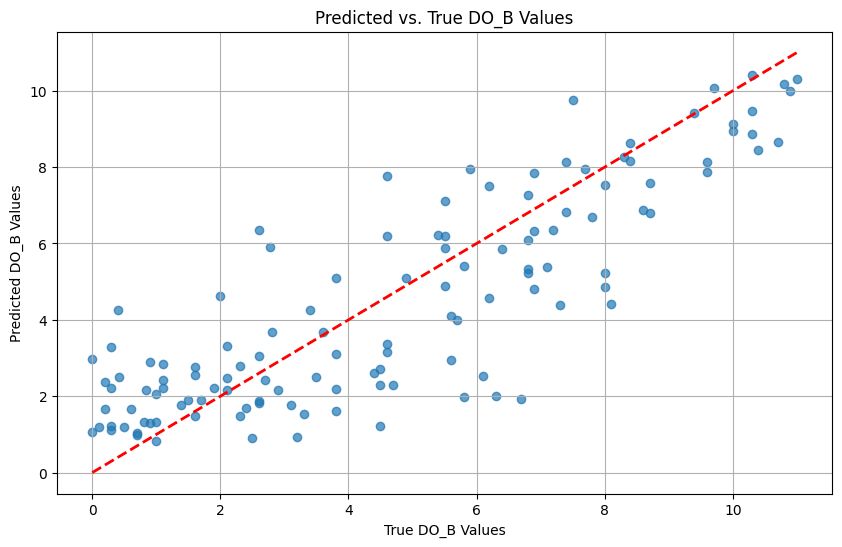

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.xlabel('True DO_B Values')
plt.ylabel('Predicted DO_B Values')
plt.title('Predicted vs. True DO_B Values')
plt.grid(True)
plt.show()

####<font color="#FF69B4">Plot one decision tree from the rf_model to show how it makes predictions using splits on the input variables. Please set the maximum tree depth to 3.

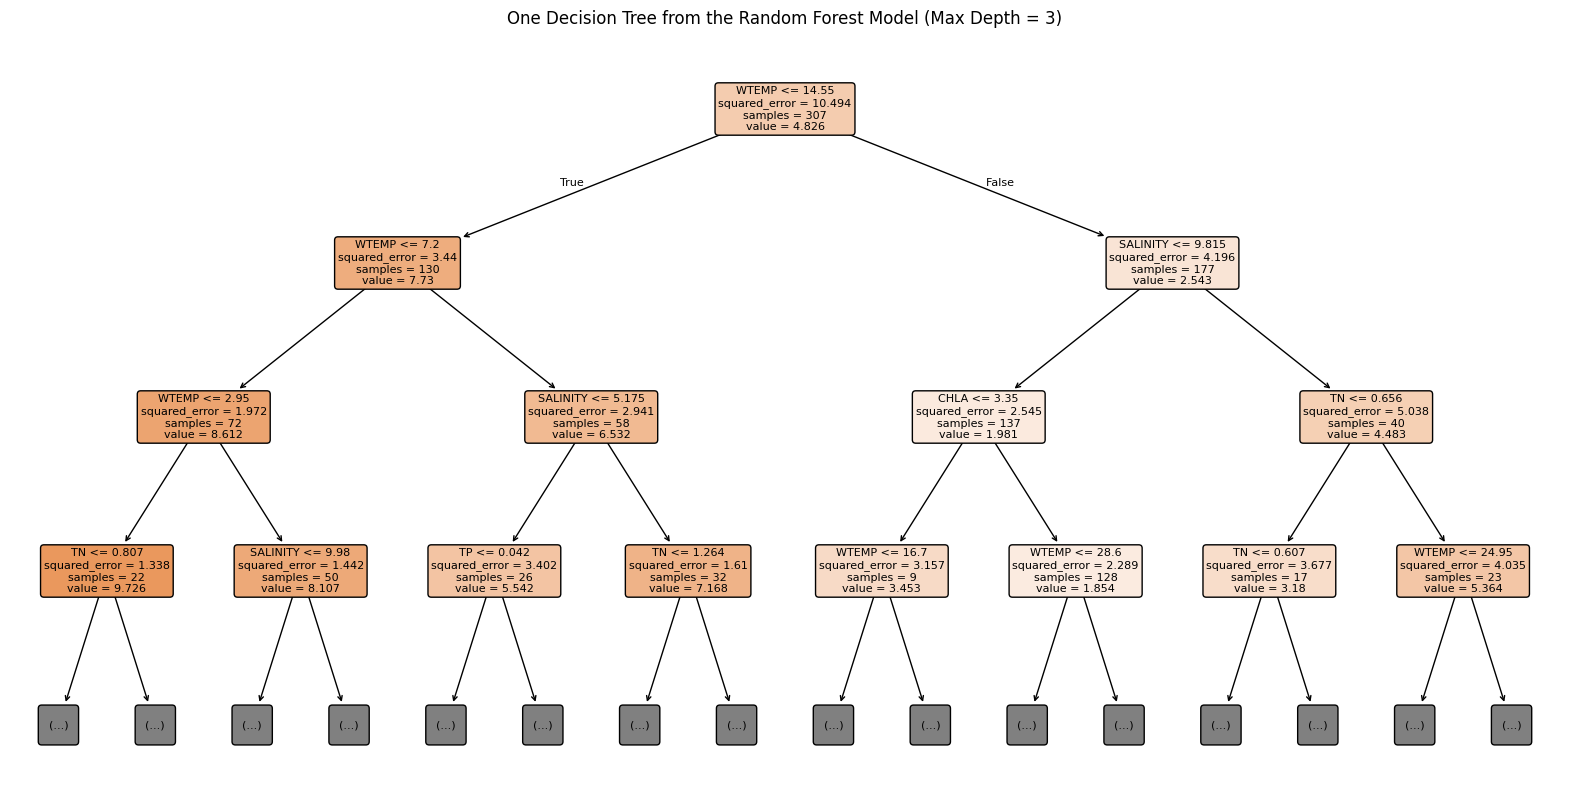

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Choose one of the estimators (decision trees) from the Random Forest model
# We'll pick the first one for simplicity
estimator = rf_model.estimators_[0]

plt.figure(figsize=(20, 10)) # Adjust figure size for better readability
plot_tree(estimator,
          feature_names=X.columns.tolist(), # Use the actual feature names
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3) # Set maximum depth as requested
plt.title('One Decision Tree from the Random Forest Model (Max Depth = 3)')
plt.show()

####<font color="#FF69B4">Use SHAP (SHapley Additive exPlanations) to interpret how each feature contributes to the rf_model predictions.

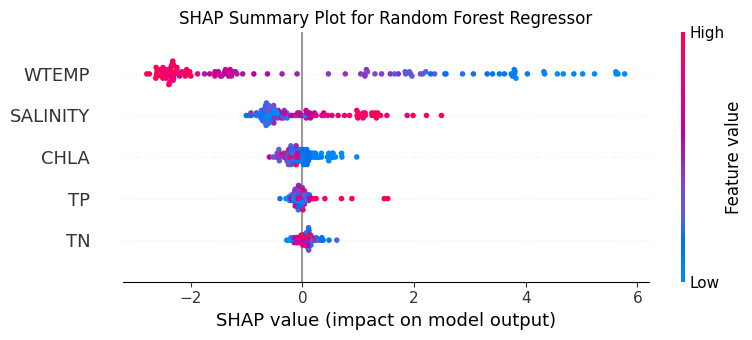

In [9]:
# Install SHAP if not already installed
# !pip install shap

import shap
import matplotlib.pyplot as plt

# Create a SHAP TreeExplainer for the Random Forest model
# TreeExplainer is optimized for tree-based models
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
# Using a subset of X_test for faster computation if the test set is large
# shap_values = explainer.shap_values(X_test)
# For a full interpretation, use the entire X_test
shap_values = explainer.shap_values(X_test)

# Visualize the feature contributions using a summary plot
# This plot shows the importance of each feature and its impact on the model output
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(), show=False)
plt.title('SHAP Summary Plot for Random Forest Regressor')
plt.tight_layout()
plt.show()

####<font color="#FF69B4">Show the average absolute contribution of each feature to the model predictions.

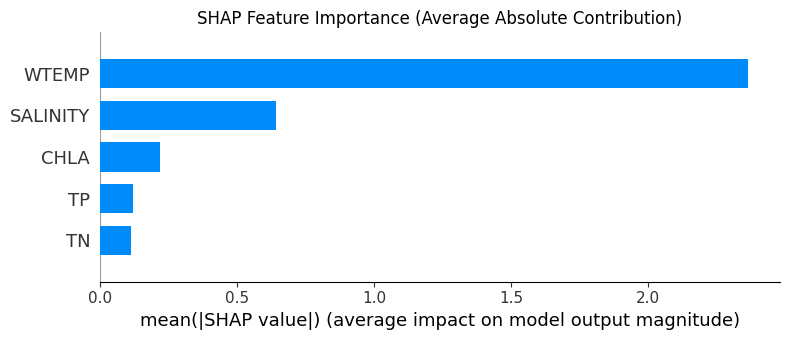

In [10]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Average Absolute Contribution)')
plt.tight_layout()
plt.show()

####<font color="#FF69B4">Visualize how each input feature influences its SHAP value using seaborn regression plots.Please add a LOWESS trend line to each plot.

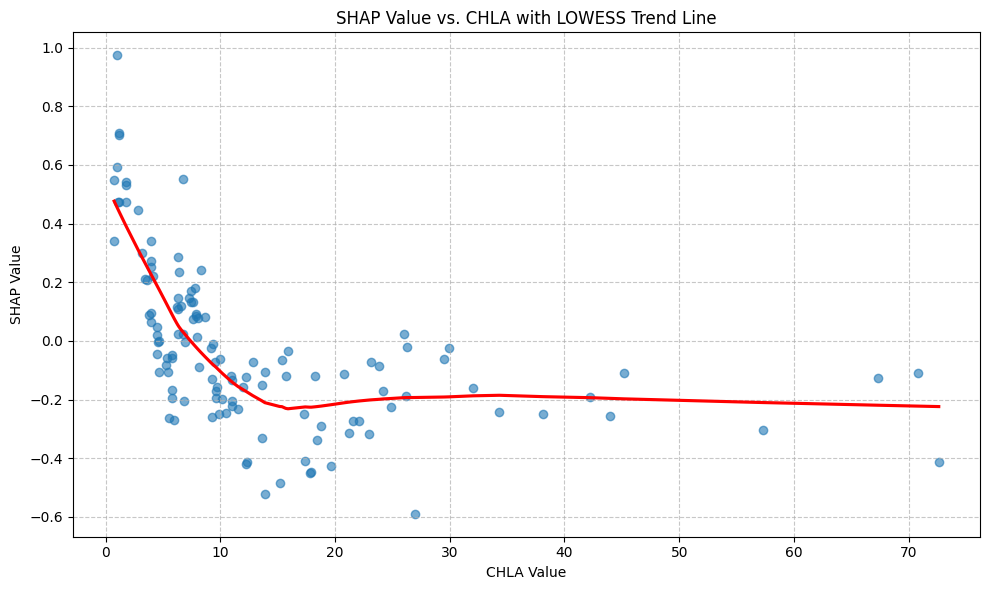

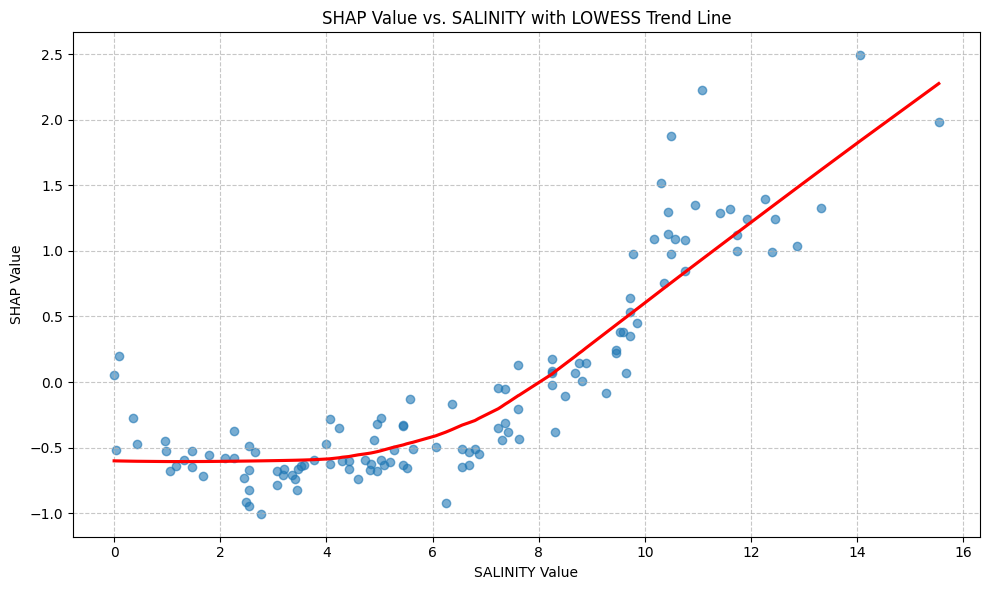

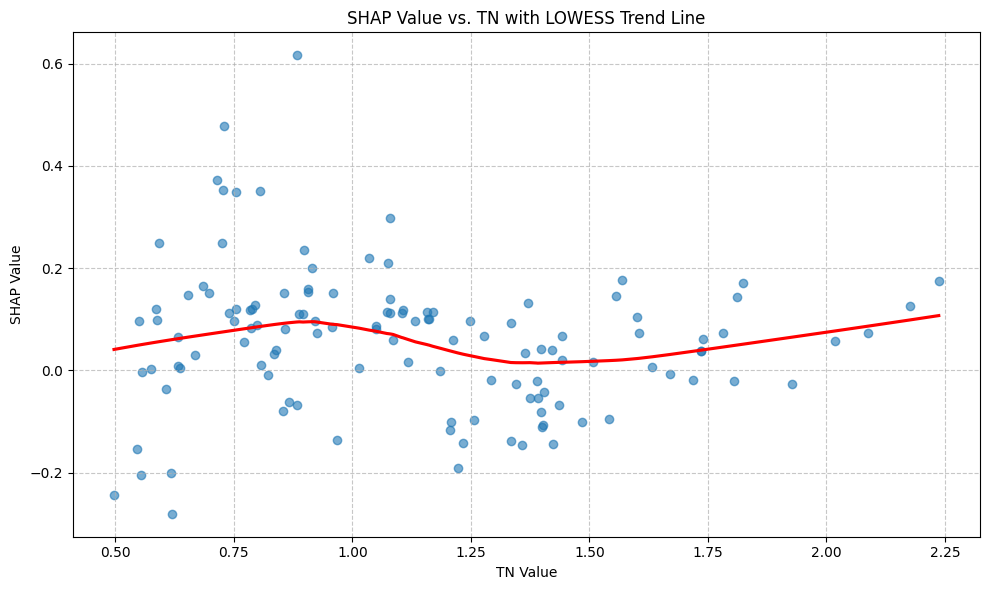

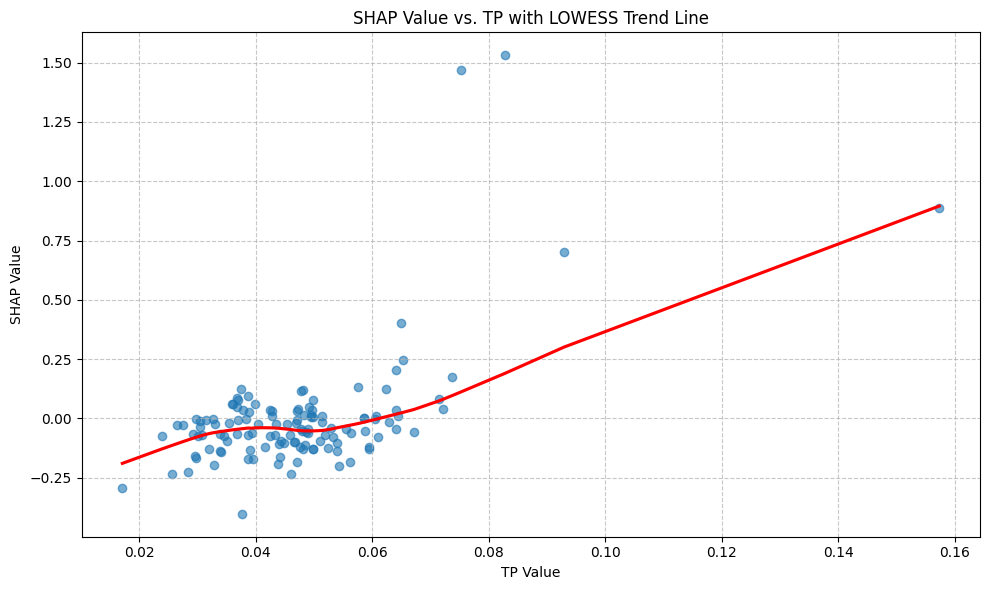

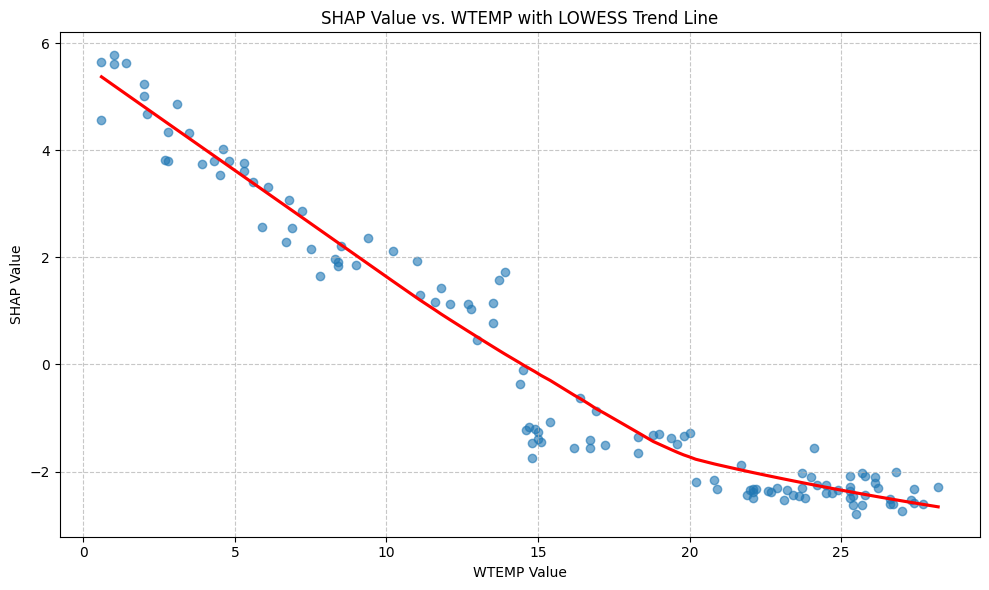

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Ensure explainer and shap_values are available from previous steps
if 'explainer' not in locals() or 'shap_values' not in locals():
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test)

# Get feature names
feature_names = X.columns.tolist()

# Iterate through each feature and create a seaborn regression plot
for i, feature in enumerate(feature_names):
    plt.figure(figsize=(10, 6))
    sns.regplot(x=X_test[feature], y=shap_values[:, i], lowess=True, scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
    plt.title(f'SHAP Value vs. {feature} with LOWESS Trend Line')
    plt.xlabel(f'{feature} Value')
    plt.ylabel('SHAP Value')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

####<font color="#FF69B4">Create the folder SavedModels/RF/Run_1

In [ ]:
import os

folder_path = 'SavedModels/RF/Run_1'
os.makedirs(folder_path, exist_ok=True)
print(f"Folder '{folder_path}' created successfully (or already exists).")

####<font color="#FF69B4">Save the trained Random Forest model in the Run_1 folder. Also, save the following information: training data used, target and feature list, train/test split ratio, number of trees

In [ ]:
import os
import joblib

# Define the folder to save the model and metadata
save_folder = 'SavedModels/RF/Run_1'

# Ensure the folder exists (it should already exist from a previous step)
os.makedirs(save_folder, exist_ok=True)

# Define the paths for the model and metadata files
model_filename = 'rf_model.pkl'
metadata_filename = 'rf_model_metadata.pkl'

model_path = os.path.join(save_folder, model_filename)
metadata_path = os.path.join(save_folder, metadata_filename)

# Save the trained Random Forest model
joblib.dump(rf_model, model_path)
print(f"Trained Random Forest model saved to: {model_path}")

# Gather the information to save
model_metadata = {
    'training_data_file': file_path, # The file path of the training data
    'training_data_shape_X': X_train.shape,
    'training_data_shape_y': y_train.shape,
    'feature_list': features,
    'target_variable': target,
    'train_test_split_ratio': '80/20',
    'test_size': 0.2, # As used in train_test_split
    'random_state_split': 42, # Assuming 42 was used for train_test_split
    'n_estimators': rf_model.n_estimators,
    'random_state_model': rf_model.random_state # Random state used for the RF model
}

# Save the metadata
joblib.dump(model_metadata, metadata_path)
print(f"Model metadata saved to: {metadata_path}")

print("\nSaved Metadata:")
for key, value in model_metadata.items():
    print(f"  {key}: {value}")

## Section 3: Model Training (MLP)

### What You Will Do

* Scale input features
* Train a neural network model
* Monitor training performance
* Evaluate and interpret results

### Key Idea

MLP is a neural network that learns patterns through layers of interconnected neurons.

Feature scaling and model parameters (e.g., learning rate, hidden layers) affect performance.

Proper training and validation are important.


####<font color="#FF69B4">Load the "CBP_CleanedData/Final_Upper_StationCB3.2.csv" as df

In [ ]:
import pandas as pd

file_path = 'CBP_CleanedData/Final_Upper_StationCB3.2.csv'
df= pd.read_csv(file_path)

print(f"DataFrame loaded from: {file_path}")
print(f"Shape of df: {df.shape}")
print("First 5 rows of df:")
print(df.head())

DataFrame loaded from: CBP_CleanedData/Final_Upper_StationCB3.2.csv
Shape of df: (617, 8)
First 5 rows of df:
  MonitoringStation  SampleDate  CHLA  SALINITY       TN     TP  WTEMP   DO
0             CB3.2  1984-07-12   2.7      1.01  1.39600  0.063   24.5  4.4
1             CB3.2  1984-07-25   5.3      0.79  1.53375  0.070   26.0  1.3
2             CB3.2  1984-08-07  17.4      3.06  1.21200  0.044   26.2  0.0
3             CB3.2  1984-08-30   6.0      6.87  1.03900  0.041   25.3  2.6
4             CB3.2  1984-09-12   7.3      7.87  0.57350  0.031   23.1  2.7


####<font color="#FF69B4">Use df, set CHLA, SALINITY, TN, TP, and WTEMP as the feature variabes X, set DO as the target variable y

In [ ]:
feature_columns = ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
target_column = 'DO'

X = df[feature_columns]
y = df[target_column]

print(f"Feature variables (X): {feature_columns}")
print(f"Target variable (y): {target_column}")
print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Feature variables (X): ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
Target variable (y): DO
Shape of features (X): (617, 5)
Shape of target (y): (617,)


####<font color="#FF69B4">Split the X and y into training and testing sets using an 80/20 ratio, name it X_train, y_train, X_test, y_test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (493, 5)
X_test shape: (124, 5)
y_train shape: (493,)
y_test shape: (124,)


####<font color="#FF69B4">Scale the input features using StandardScaler to normalize both the training and test data.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")

Features scaled successfully!
Shape of X_train_scaled: (493, 5)
Shape of X_test_scaled: (124, 5)


###<font color="#FF69B4">Use TensorFlow to train a 2-layer MLP model using the training data. Use 64 neurons in the first layer and 32 neurons in the second layer. Please train the model for 100 epochs with a batch size of 32, use a validation split of 0.2, and apply early stopping. Please name the model mlp_model. Please plot the MSE loss for both training and validation over epochs to assess the learning process. There is no need to predict on the test data at this stage.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MLP model trained successfully!


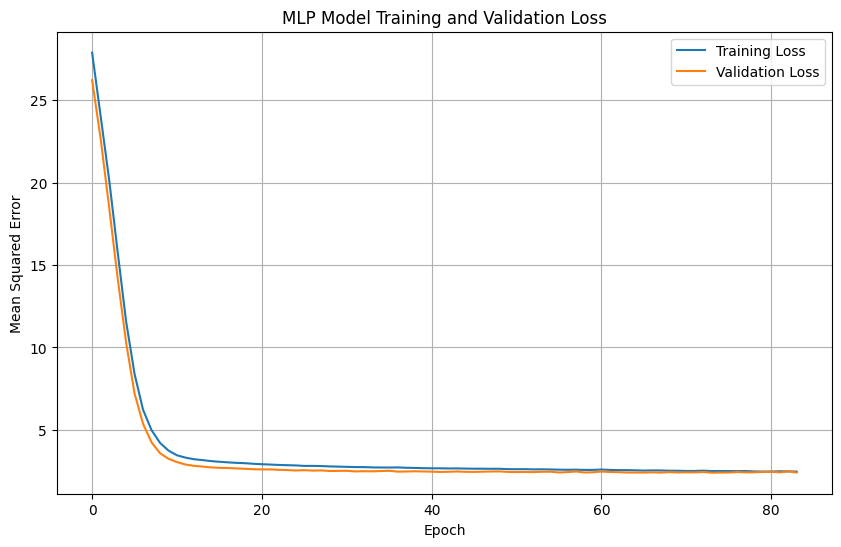

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define the MLP model
mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression
])

# Compile the model
mlp_model.compile(optimizer='adam', loss='mean_squared_error')

# Define Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = mlp_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

print("MLP model trained successfully!")

# Plotting the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MLP Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

###<font color="#FF69B4">Evaluate the MLP_model performance on the test set using RMSE and R², plot predicted and true DO values to visually assess model performance.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
MLP Model Performance on Test Set:
RMSE: 1.5540
R-squared: 0.7636


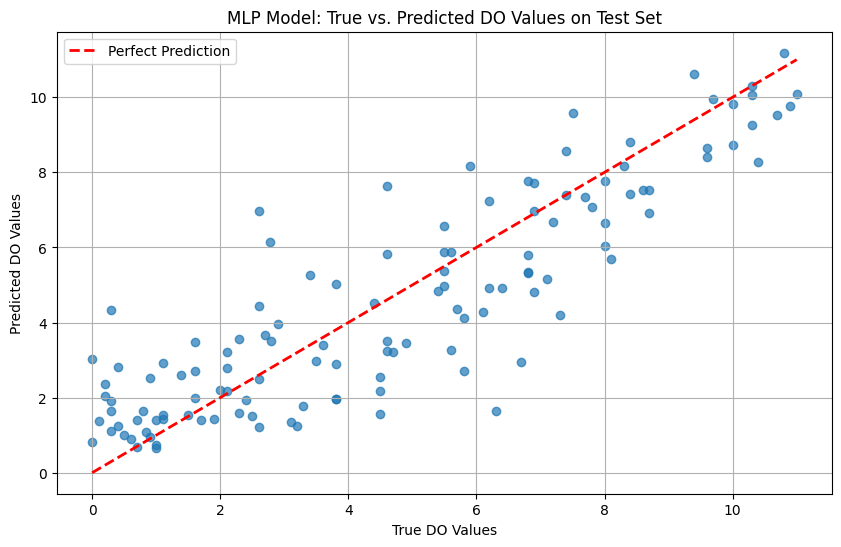

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = mlp_model.predict(X_test_scaled).flatten()

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

print(f"MLP Model Performance on Test Set:")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

# Plot predicted vs. true DO values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True DO Values')
plt.ylabel('Predicted DO Values')
plt.title('MLP Model: True vs. Predicted DO Values on Test Set')
plt.legend()
plt.grid(True)
plt.show()

###<font color="#FF69B4">Use SHAP (SHapley Additive exPlanations) to interpret how each feature contributes to the mlp_model predictions, and visualize with summary_plot

Calculating SHAP values... This may take a moment.
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


ExactExplainer explainer:  10%|▉         | 12/124 [00:00<?, ?it/s]

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


ExactExplainer explainer:  11%|█▏        | 14/124 [00:10<00:28,  3.80it/s]

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


...

ExactExplainer explainer:  99%|█████████▉| 123/124 [00:56<00:00,  2.45it/s]

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer: 100%|██████████| 124/124 [00:56<00:00,  2.50it/s]

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer: 125it [00:56,  1.98it/s]


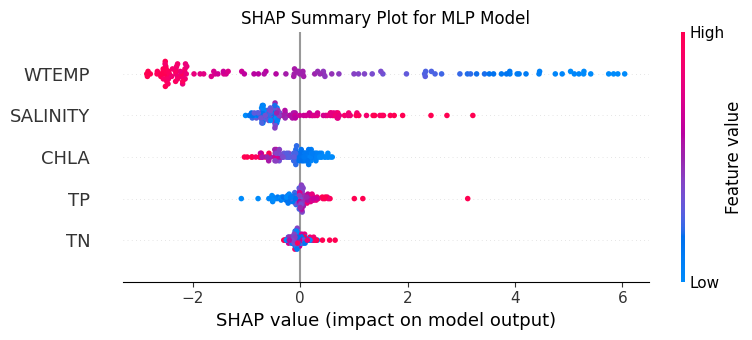

SHAP summary plot generated successfully.


In [ ]:
import shap
import numpy as np

# Assuming mlp_model, X_train_scaled, X_test_scaled, and feature_columns are already defined.

# Create a SHAP explainer
# For Keras models, we need to wrap the predict method
explainer = shap.Explainer(mlp_model.predict, X_train_scaled)

# Calculate SHAP values for the test set
# This might take a while depending on the size of X_test_scaled
print("Calculating SHAP values... This may take a moment.")
shap_values = explainer(X_test_scaled)

# Ensure shap_values is a 2D array if the model output is 1D for regression
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# Visualize the SHAP values using a summary plot
# We pass the original X_test DataFrame for feature names
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_columns, show=False)
plt.title('SHAP Summary Plot for MLP Model')
plt.tight_layout()
plt.show()

print("SHAP summary plot generated successfully.")

###<font color="#FF69B4">Plot the average absolute contribution of each feature to the model predictions

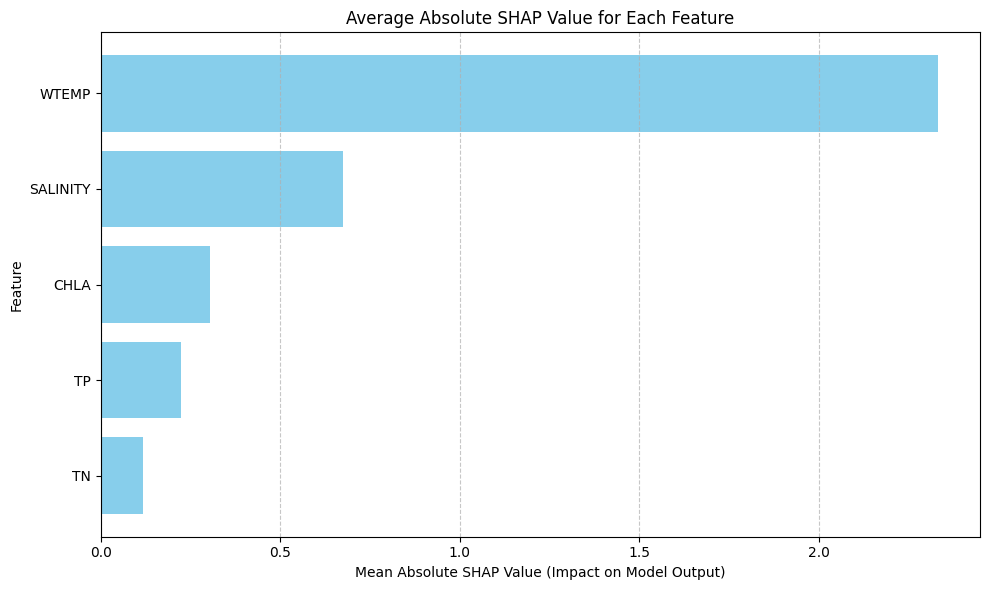

Average Absolute Contribution of Each Feature to MLP Model Predictions:
 Feature  Mean Absolute SHAP Value
   WTEMP                  2.332591
SALINITY                  0.675697
    CHLA                  0.303737
      TP                  0.223346
      TN                  0.116273


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure shap_values_array is correctly assigned
# It seems `shap_values` is already a numpy array from the previous cell's output (KTx6-xyfQlfp)
# If it were a list, we'd need to take the first element as done before.

# Safely get shap_values_array, accounting for potential list output from explainer
if isinstance(shap_values, list):
    shap_values_array = shap_values[0]
else:
    # If shap_values is a shap.Explanation object, get its values attribute
    shap_values_array = shap_values.values if hasattr(shap_values, 'values') else shap_values

# Calculate the mean absolute SHAP value for each feature
mean_abs_shap_values = np.mean(np.abs(shap_values_array), axis=0)

# Create a DataFrame for better visualization
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Mean Absolute SHAP Value': mean_abs_shap_values
})

# Sort by importance for better plot readability
feature_importance = feature_importance.sort_values(by='Mean Absolute SHAP Value', ascending=False)

# Plotting the average absolute contribution
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Mean Absolute SHAP Value'], color='skyblue')
plt.xlabel('Mean Absolute SHAP Value (Impact on Model Output)')
plt.ylabel('Feature')
plt.title('Average Absolute SHAP Value for Each Feature')
plt.gca().invert_yaxis() # To have the most important feature at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Average Absolute Contribution of Each Feature to MLP Model Predictions:")
print(feature_importance.to_string(index=False))

####<font color="#FF69B4">Visualize how each input feature influences its SHAP value using seaborn regression plots.Please add a LOWESS trend line to each plot.

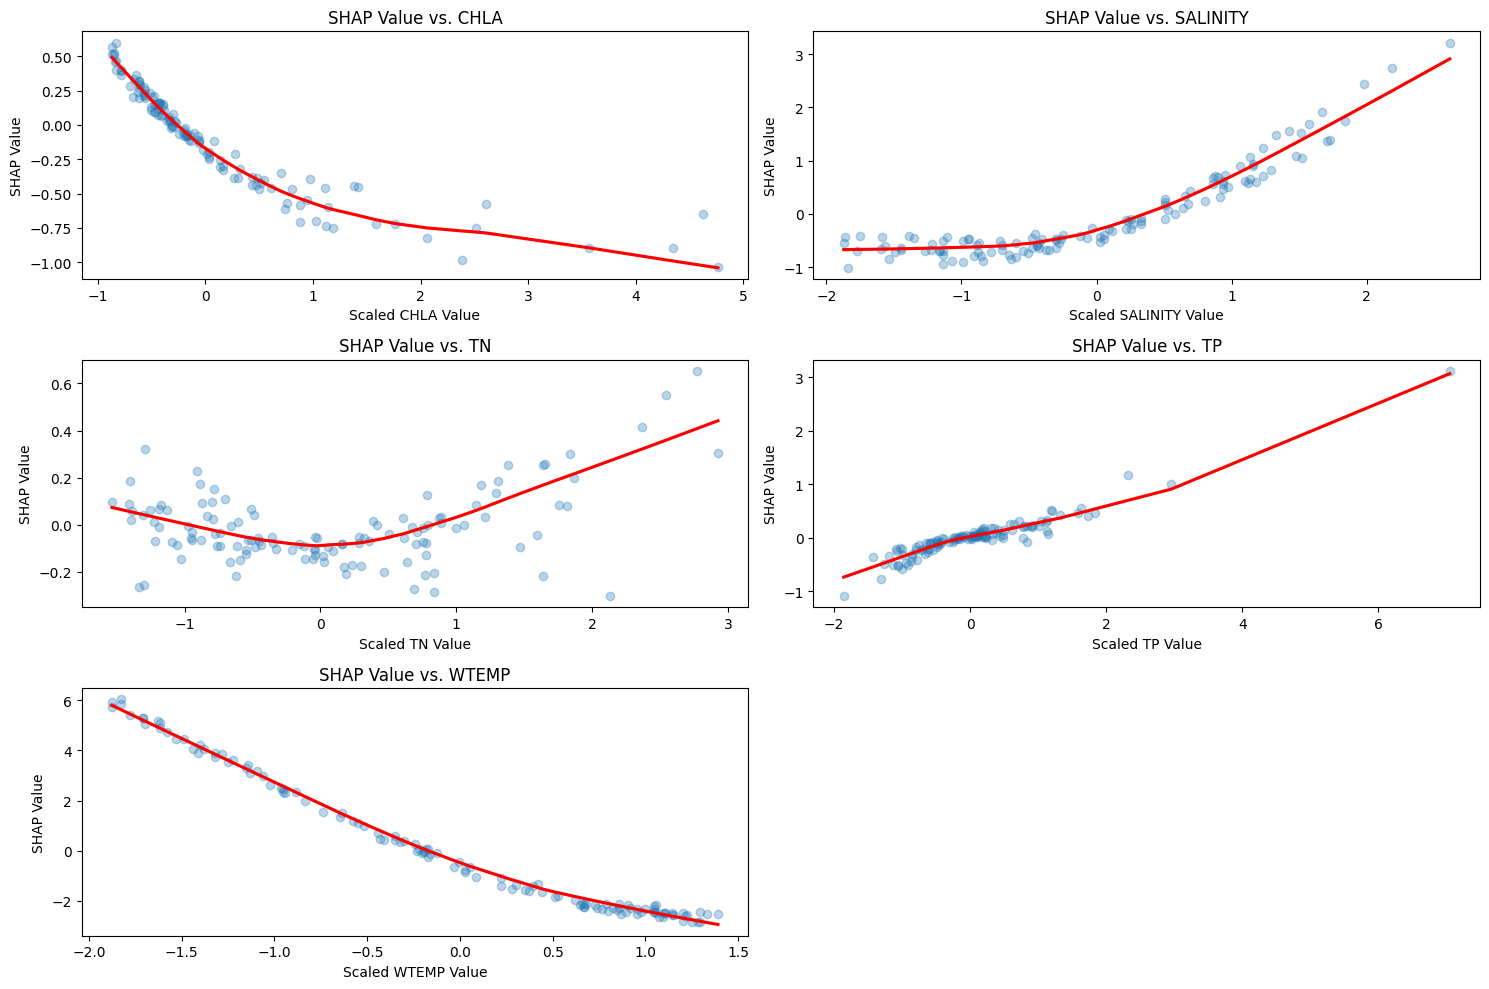

Individual feature influence plots generated successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure shap_values_array is correctly assigned as a numpy array
if isinstance(shap_values, list):
    shap_values_array = shap_values[0]
else:
    shap_values_array = shap_values.values if hasattr(shap_values, 'values') else shap_values

# Assuming X_test_scaled is a numpy array and feature_columns is a list of feature names

plt.figure(figsize=(15, 10))
num_features = len(feature_columns)
rows = int(np.ceil(num_features / 2))
cols = 2

for i, feature_name in enumerate(feature_columns):
    plt.subplot(rows, cols, i + 1)
    sns.regplot(x=X_test_scaled[:, i], y=shap_values_array[:, i], lowess=True, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'SHAP Value vs. {feature_name}')
    plt.xlabel(f'Scaled {feature_name} Value')
    plt.ylabel('SHAP Value')

plt.tight_layout()
plt.show()

print("Individual feature influence plots generated successfully.")

###<font color="#FF69B4">Create the folder SavedModels/MLP/Run_1

In [ ]:
import os

folder_path = 'SavedModels/MLP/Run_1'
os.makedirs(folder_path, exist_ok=True)
print(f"Folder '{folder_path}' created successfully!")

Folder 'SavedModels/MLP/Run_1' created successfully!


###<font color="#FF69B4">Save the trained MLP model in the Run_1 folder as mlp_model.h5. Please include the training data used, target and feature list, and other metadata of the model.

In [ ]:
import os
import json
import tensorflow as tf
import numpy as np # Import numpy for float conversion

# Define the path to save the model and metadata
model_save_path = os.path.join(folder_path, 'mlp_model.h5')

# Save the Keras MLP model
mlp_model.save(model_save_path)
print(f"MLP model saved successfully to: {model_save_path}")

# Prepare model metadata
metadata = {
    'model_name': 'MLP Regression Model',
    'feature_columns': feature_columns,
    'target_column': target_column,
    'training_data_info': {
        'X_train_shape': list(X_train.shape),
        'y_train_shape': list(y_train.shape)
    },
    'test_data_info': {
        'X_test_shape': list(X_test.shape),
        'y_test_shape': list(y_test.shape)
    },
    'model_evaluation_metrics': {
        'test_rmse': float(rmse), # Convert numpy float to standard float
        'test_r2': float(r2)     # Convert numpy float to standard float
    },
    'preprocessing': {
        'scaling': 'StandardScaler'
    },
    'model_architecture_summary': [], # Will populate with summary
    'notes': 'Trained with 2-layer MLP (64-32 neurons), 100 epochs, batch size 32, validation split 0.2, early stopping.'
}

# Get model architecture summary and add it to metadata
# Redirect print output to a string to capture summary
import io
from contextlib import redirect_stdout
f = io.StringIO()
with redirect_stdout(f):
    mlp_model.summary()
s = f.getvalue()
metadata['model_architecture_summary'] = s.splitlines()

# Save metadata to a JSON file
metadata_save_path = os.path.join(folder_path, 'mlp_model_metadata.json')
with open(metadata_save_path, 'w') as f_json:
    json.dump(metadata, f_json, indent=4)
print(f"Model metadata saved successfully to: {metadata_save_path}")

print("Contents of the saved metadata file:")
print(json.dumps(metadata, indent=4))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,493 (29.27 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,996 (19.52 KB)

MLP model saved successfully to: SavedModels/MLP/Run_1/mlp_model.h5
Model metadata saved successfully to: SavedModels/MLP/Run_1/mlp_model_metadata.json
Contents of the saved metadata file:
{
    "model_name": "MLP Regression Model",
    "feature_columns": [
        "CHLA",
        "SALINITY",
        "TN",
        "TP",
        "WTEMP"
    ],
    "target_column": "DO",
    "training_data_info": {
        "X_train_shape": [
            493,
            5
        ],
        "y_train_shape": [
            493
        ]
    },
    "test_data_info": {
        "X_test_shape": [
            124,
            5
        ],
        "y_test_shape": [
            124
        ]
    },
    "model_evaluation_metrics": {
        "test_rmse": 1.5539756632352264,
        "test_r2": 0.763639351413466
    },
    "preprocessing": {
        "scaling": "StandardScaler"
    },
    "model_architecture_summary": [],
    "notes": "Trained with 2-layer MLP (64-32 neurons), 100 epochs, batch size 32, validation spl

## Wrap-Up

### What You Did

* Cleaned and prepared raw environmental data
* Trained and evaluated Random Forest and MLP models
* Interpreted model behavior using SHAP
* Applied models to predict bottom dissolved oxygen at another station

### Key Idea

A complete machine learning workflow connects data, models, and interpretation.

Good data and the right model choice lead to better predictions.


####<font color="#FF69B4">Use joblib load the model from SavedModels/RF/Run_1/rf_model.pkl. Features are CHLA, SALINITY, TN, TP, and WTEMP, DO is the target variable. Then, test it on a new station dataset: CBP_CleanedData/Final_Middle_StationCB5.1.csv. Name the prediction RF_Predicted_DO. Also, Please plot the scatter plot of true DO vs Predicted DO from RF for visualization.

Loading model from: /content/NAIRR-2026-Tutorial-Intro-ML-Predict-DO/SavedModels/RF/Run_1/rf_model.pkl
Loading dataset from: /content/NAIRR-2026-Tutorial-Intro-ML-Predict-DO/CBP_CleanedData/Final_Middle_StationCB5.1.csv
Features for prediction: ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
Target variable for comparison: DO
Random Forest model loaded successfully.
New station dataset loaded successfully.

First 5 rows of the new dataset:
  MonitoringStation SampleDate  CHLA  SALINITY       TN     TP  WTEMP   DO
0             CB5.1    7/24/84   6.7      9.01  1.20600  0.024   26.1  0.1
1             CB5.1    9/24/84   8.7     15.54  0.32325  0.025   23.4  2.3
2             CB5.1    10/8/84  13.4     14.80  0.96400  0.029   18.3  4.8
3             CB5.1   10/22/84   9.3     15.41  0.72700  0.017   19.6  4.9
4             CB5.1    11/5/84   6.7     15.75  0.63000  0.019   17.9  2.5

True DO values found in dataset (first 5):
0    0.1
1    2.3
2    4.8
3    4.9
4    2.5
Name: DO, dtype: float6

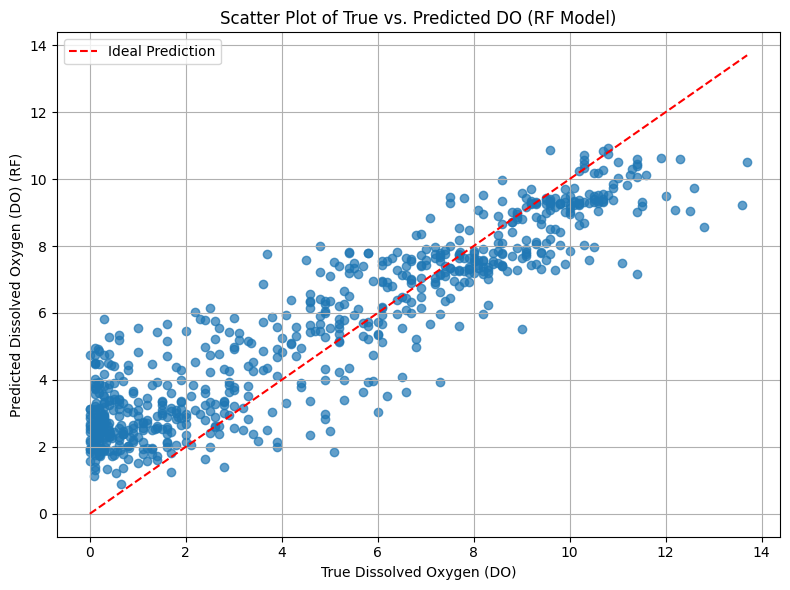

In [ ]:
import pandas as pd
import joblib
import os
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Define paths relative to the current working directory
model_path = './SavedModels/RF/Run_1/rf_model.pkl'
dataset_path = './CBP_CleanedData/Final_Middle_StationCB5.1.csv'

# Define features and target as specified by the user
feature_columns = ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
target_variable = 'DO'
prediction_column_name = 'RF_Predicted_DO'

print(f"Loading model from: {os.path.abspath(model_path)}")
print(f"Loading dataset from: {os.path.abspath(dataset_path)}")
print(f"Features for prediction: {feature_columns}")
print(f"Target variable for comparison: {target_variable}")

try:
    # Load the Random Forest model
    rf_model = joblib.load(model_path)
    print("Random Forest model loaded successfully.")

    # Load the new station dataset
    new_data = pd.read_csv(dataset_path)
    print("New station dataset loaded successfully.")

    # Display first few rows of the dataset to understand its structure
    print("\nFirst 5 rows of the new dataset:")
    print(new_data.head())

    # Check if all specified feature columns are in the new dataset
    missing_features = [col for col in feature_columns if col not in new_data.columns]
    if missing_features:
        raise ValueError(f"The following required features are missing in the new dataset: {missing_features}")

    # Prepare the feature matrix for prediction
    X_test = new_data[feature_columns]

    # Extract the true target variable if it exists in the dataset
    if target_variable in new_data.columns:
        y_true = new_data[target_variable]
        print(f"\nTrue {target_variable} values found in dataset (first 5):\n{y_true.head()}")
    else:
        y_true = None
        print(f"\nWarning: '{target_variable}' column not found in the dataset. Only predictions will be made.")

    # Handle potential missing values in the test set if the model expects no NaNs
    if X_test.isnull().any().any():
        print("\nWarning: Missing values found in test features. Filling with column mean.")
        X_test = X_test.fillna(X_test.mean())

    # Make predictions
    predictions = rf_model.predict(X_test)
    print("\nPredictions made successfully.")

    # Add predictions to the dataframe with the specified name
    new_data[prediction_column_name] = predictions

    print(f"\nFirst 10 rows with True {target_variable} and {prediction_column_name}:")
    if y_true is not None:
        print(new_data[[target_variable, prediction_column_name]].head(10))
    else:
        print(new_data[[prediction_column_name]].head(10))

    # If true values are available, calculate performance metrics
    if y_true is not None:
        mse = mean_squared_error(y_true, predictions)
        r2 = r2_score(y_true, predictions)
        print(f"\nModel performance on new dataset:")
        print(f"Mean Squared Error: {mse:.2f}")
        print(f"R-squared: {r2:.2f}")

    # Plotting for visualization as requested: Scatter plot of True DO vs Predicted DO
    if y_true is not None:
        plt.figure(figsize=(8, 6))
        plt.scatter(y_true, new_data[prediction_column_name], alpha=0.7)
        plt.xlabel('True Dissolved Oxygen (DO)')
        plt.ylabel('Predicted Dissolved Oxygen (DO) (RF)')
        plt.title('Scatter Plot of True vs. Predicted DO (RF Model)')
        plt.grid(True)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal Prediction') # Add a diagonal line for ideal prediction
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("\nCannot plot scatter plot: True DO values not available in the dataset.")

except FileNotFoundError as e:
    print(f"Error: One of the files was not found. Please check the paths. {e}")
except ValueError as e:
    print(f"An error occurred with data processing: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

####<font color="#FF69B4">Plot SampleDate on the x-axis and compare the true DO and predicted DO values.

/tmp/ipykernel_5586/3604034917.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_data['SampleDate'] = pd.to_datetime(new_data['SampleDate'])


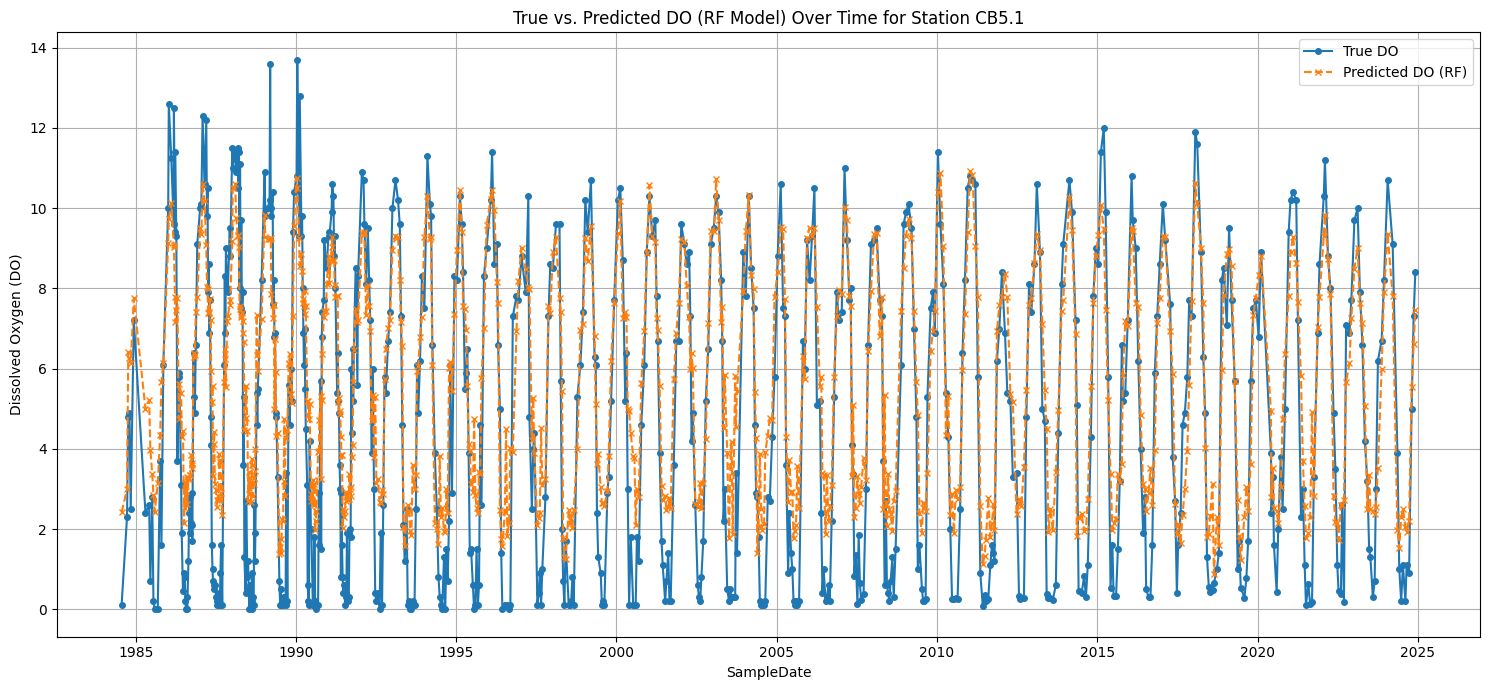

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure SampleDate is in datetime format
if not pd.api.types.is_datetime64_any_dtype(new_data['SampleDate']):
    new_data['SampleDate'] = pd.to_datetime(new_data['SampleDate'])

plt.figure(figsize=(15, 7))
plt.plot(new_data['SampleDate'], new_data['DO'], label='True DO', marker='o', linestyle='-', markersize=4)
plt.plot(new_data['SampleDate'], new_data['RF_Predicted_DO'], label='Predicted DO (RF)', marker='x', linestyle='--', markersize=4)

plt.xlabel('SampleDate')
plt.ylabel('Dissolved Oxygen (DO)')
plt.title('True vs. Predicted DO (RF Model) Over Time for Station CB5.1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

####<font color="#FF69B4">Load the model from SavedModels/MLP/Run_1/mlp_model.h5. Features are CHLA, SALINITY, TN, TP, and WTEMP, DO is the target variable. Then, test it on a new station dataset: CBP_CleanedData/Final_Middle_StationCB5.1.csv. Use the standard scaler to scale the data.Name the prediction MLP_Predicted_DO Also, Please plot the scatter plot of true DO vs Predicted DO for visualization.

Loading MLP model from: /content/NAIRR-2026-Tutorial-Intro-ML-Predict-DO/SavedModels/MLP/Run_1/mlp_model.h5
Loading dataset from: /content/NAIRR-2026-Tutorial-Intro-ML-Predict-DO/CBP_CleanedData/Final_Middle_StationCB5.1.csv
Features for prediction: ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
Target variable for comparison: DO
MLP model loaded successfully.
New station dataset loaded successfully for MLP prediction.

First 5 rows of the new dataset (for MLP):
  MonitoringStation SampleDate  CHLA  SALINITY       TN     TP  WTEMP   DO
0             CB5.1    7/24/84   6.7      9.01  1.20600  0.024   26.1  0.1
1             CB5.1    9/24/84   8.7     15.54  0.32325  0.025   23.4  2.3
2             CB5.1    10/8/84  13.4     14.80  0.96400  0.029   18.3  4.8
3             CB5.1   10/22/84   9.3     15.41  0.72700  0.017   19.6  4.9
4             CB5.1    11/5/84   6.7     15.75  0.63000  0.019   17.9  2.5

True DO values found in dataset (first 5) for MLP:
0    0.1
1    2.3
2    4.8
3    4.9


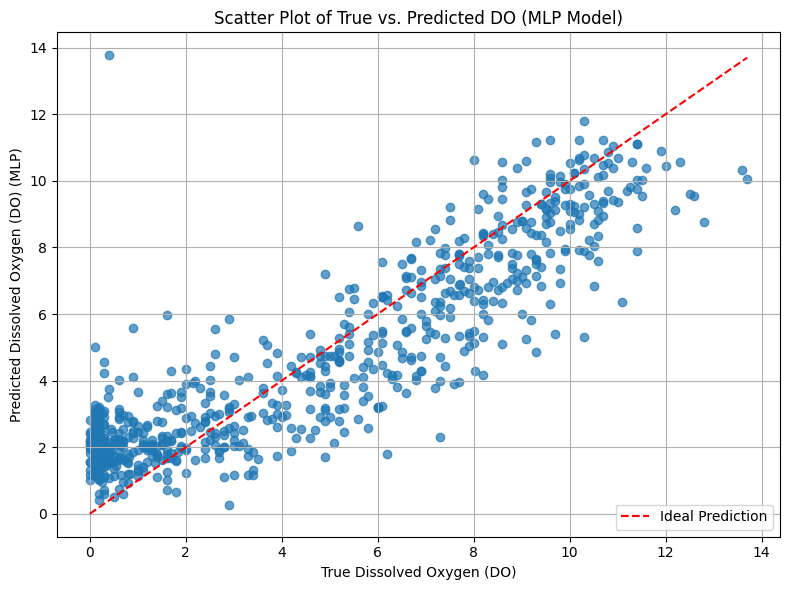

In [ ]:
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import os

# Define paths relative to the current working directory
mlp_model_path = './SavedModels/MLP/Run_1/mlp_model.h5'
dataset_path = './CBP_CleanedData/Final_Middle_StationCB5.1.csv'

# Define features and target as specified by the user
feature_columns = ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
target_variable = 'DO'
mlp_prediction_column_name = 'MLP_Predicted_DO'

print(f"Loading MLP model from: {os.path.abspath(mlp_model_path)}")
print(f"Loading dataset from: {os.path.abspath(dataset_path)}")
print(f"Features for prediction: {feature_columns}")
print(f"Target variable for comparison: {target_variable}")

try:
    # Load the MLP model
    mlp_model = tf.keras.models.load_model(mlp_model_path)
    print("MLP model loaded successfully.")

    # Load the new station dataset
    new_data_mlp = pd.read_csv(dataset_path)
    print("New station dataset loaded successfully for MLP prediction.")

    # Display first few rows of the dataset to understand its structure
    print("\nFirst 5 rows of the new dataset (for MLP):")
    print(new_data_mlp.head())

    # Check if all specified feature columns are in the new dataset
    missing_features = [col for col in feature_columns if col not in new_data_mlp.columns]
    if missing_features:
        raise ValueError(f"The following required features are missing in the new dataset: {missing_features}")

    # Prepare the feature matrix for prediction
    X_test_mlp = new_data_mlp[feature_columns].copy()

    # Extract the true target variable if it exists in the dataset
    if target_variable in new_data_mlp.columns:
        y_true_mlp = new_data_mlp[target_variable]
        print(f"\nTrue {target_variable} values found in dataset (first 5) for MLP:\n{y_true_mlp.head()}")
    else:
        y_true_mlp = None
        print(f"\nWarning: '{target_variable}' column not found in the dataset. Only predictions will be made.")

    # Handle potential missing values in the test set
    if X_test_mlp.isnull().any().any():
        print("\nWarning: Missing values found in test features. Filling with column mean.")
        X_test_mlp = X_test_mlp.fillna(X_test_mlp.mean())

    # Initialize and fit StandardScaler (or load if saved previously)
    # IMPORTANT: In a real scenario, you should load the *same* scaler that was used to train the model
    # For this exercise, we fit a new one for demonstration.
    scaler = StandardScaler()
    X_test_scaled = scaler.fit_transform(X_test_mlp)
    print("Data scaled using StandardScaler.")

    # Make predictions
    mlp_predictions = mlp_model.predict(X_test_scaled).flatten()
    print("\nMLP predictions made successfully.")

    # Add predictions to the dataframe with the specified name
    new_data_mlp[mlp_prediction_column_name] = mlp_predictions

    # Update the global `new_data` DataFrame with MLP predictions
    # This assumes `new_data` from the RF prediction cell is available and will be used later
    if 'new_data' in globals():
        new_data[mlp_prediction_column_name] = mlp_predictions
        print("MLP predictions added to the existing 'new_data' DataFrame.")
    else:
        new_data = new_data_mlp # If `new_data` doesn't exist, create it with MLP data
        print("Created 'new_data' DataFrame with MLP predictions.")

    print(f"\nFirst 10 rows with True {target_variable} and {mlp_prediction_column_name}:")
    if y_true_mlp is not None:
        print(new_data_mlp[[target_variable, mlp_prediction_column_name]].head(10))
    else:
        print(new_data_mlp[[mlp_prediction_column_name]].head(10))

    # If true values are available, calculate performance metrics
    if y_true_mlp is not None:
        mse_mlp = mean_squared_error(y_true_mlp, mlp_predictions)
        r2_mlp = r2_score(y_true_mlp, mlp_predictions)
        print(f"\nMLP Model performance on new dataset:")
        print(f"Mean Squared Error: {mse_mlp:.2f}")
        print(f"R-squared: {r2_mlp:.2f}")

    # Plotting for visualization as requested: Scatter plot of True DO vs Predicted DO
    if y_true_mlp is not None:
        plt.figure(figsize=(8, 6))
        plt.scatter(y_true_mlp, new_data_mlp[mlp_prediction_column_name], alpha=0.7)
        plt.xlabel('True Dissolved Oxygen (DO)')
        plt.ylabel('Predicted Dissolved Oxygen (DO) (MLP)')
        plt.title('Scatter Plot of True vs. Predicted DO (MLP Model)')
        plt.grid(True)
        plt.plot([y_true_mlp.min(), y_true_mlp.max()], [y_true_mlp.min(), y_true_mlp.max()], 'r--', label='Ideal Prediction') # Add a diagonal line for ideal prediction
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("\nCannot plot scatter plot: True DO values not available in the dataset.")

except FileNotFoundError as e:
    print(f"Error: One of the files was not found. Please check the paths. {e}")
except ValueError as e:
    print(f"An error occurred with data processing: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

####<font color="#FF69B4">Plot SampleDate on the x-axis and compare the true DO and predicted DO values from the MLP prediction.

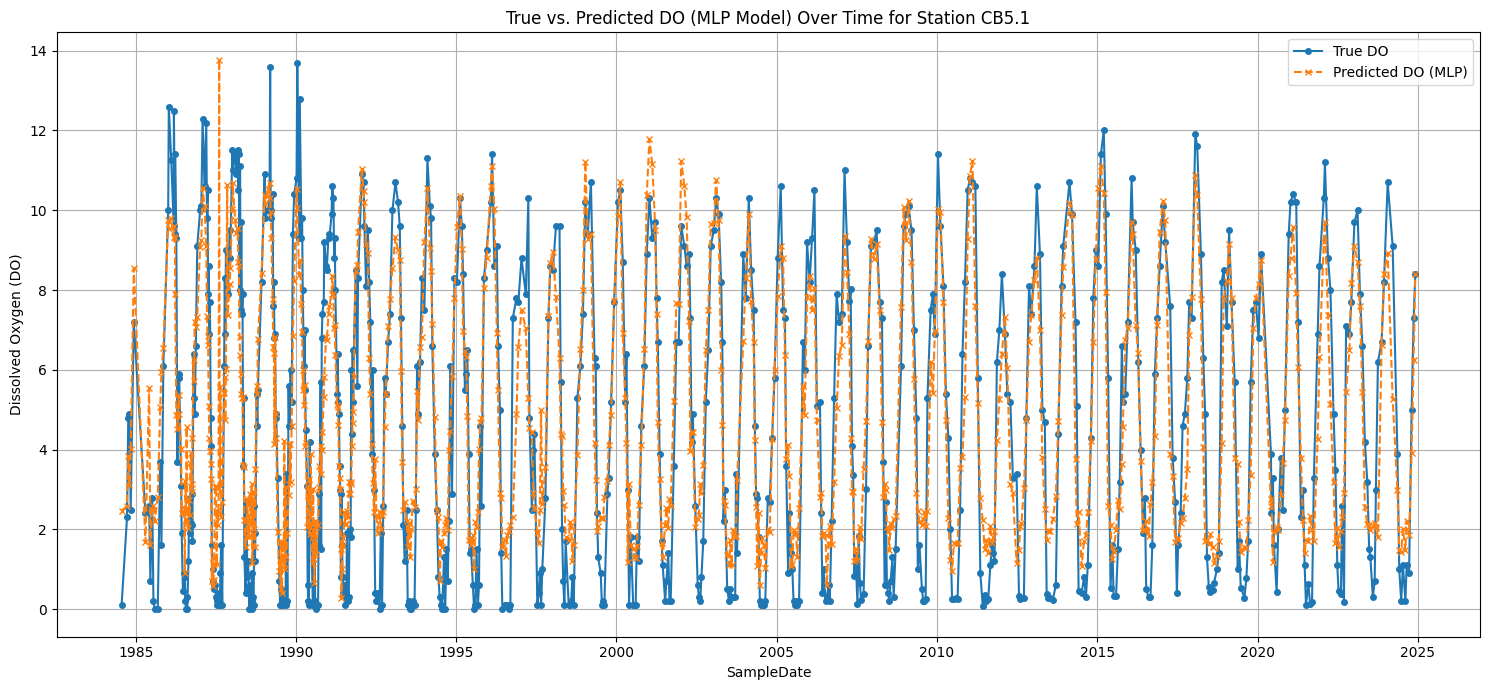

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure SampleDate is in datetime format
# Check if 'SampleDate' is already datetime, if not, convert it
if not pd.api.types.is_datetime64_any_dtype(new_data['SampleDate']):
    new_data['SampleDate'] = pd.to_datetime(new_data['SampleDate'])

plt.figure(figsize=(15, 7))
plt.plot(new_data['SampleDate'], new_data['DO'], label='True DO', marker='o', linestyle='-', markersize=4)
plt.plot(new_data['SampleDate'], new_data['MLP_Predicted_DO'], label='Predicted DO (MLP)', marker='x', linestyle='--', markersize=4)

plt.xlabel('SampleDate')
plt.ylabel('Dissolved Oxygen (DO)')
plt.title('True vs. Predicted DO (MLP Model) Over Time for Station CB5.1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

####<font color="#FF69B4">Plot SampleDate on the x-axis and compare the true DO and predicted DO values from both the RF and the MLP prediction.

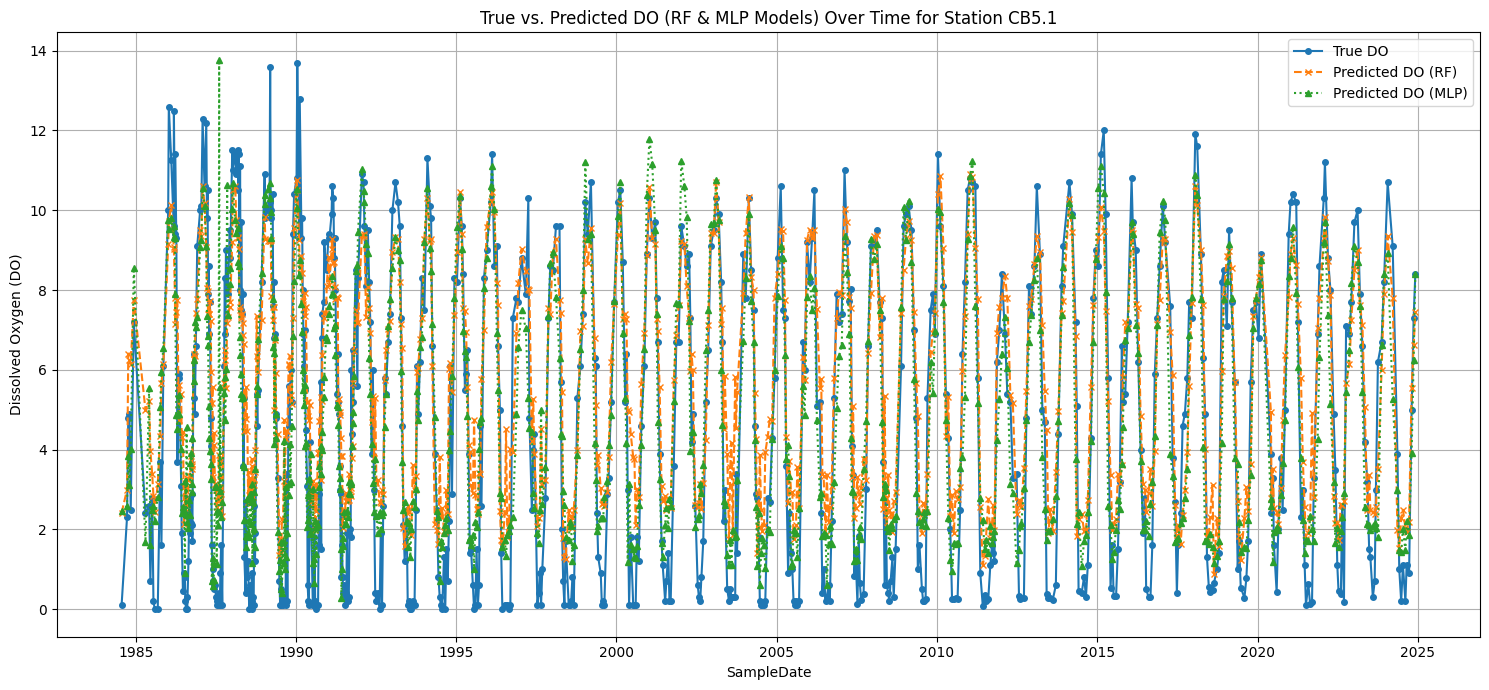

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure SampleDate is in datetime format
# Check if 'SampleDate' is already datetime, if not, convert it
if not pd.api.types.is_datetime64_any_dtype(new_data['SampleDate']):
    new_data['SampleDate'] = pd.to_datetime(new_data['SampleDate'])

# Re-add RF_Predicted_DO to new_data as it might have been overwritten by subsequent cell executions
# The 'predictions' variable from the RF model cell (GUgr4Guz-Uns) should still be available in the kernel state.
if 'predictions' in globals() and 'RF_Predicted_DO' not in new_data.columns:
    new_data['RF_Predicted_DO'] = predictions
    print("RF_Predicted_DO column re-added to new_data.")

plt.figure(figsize=(15, 7))
plt.plot(new_data['SampleDate'], new_data['DO'], label='True DO', marker='o', linestyle='-', markersize=4)
plt.plot(new_data['SampleDate'], new_data['RF_Predicted_DO'], label='Predicted DO (RF)', marker='x', linestyle='--', markersize=4)
plt.plot(new_data['SampleDate'], new_data['MLP_Predicted_DO'], label='Predicted DO (MLP)', marker='^', linestyle=':', markersize=4)

plt.xlabel('SampleDate')
plt.ylabel('Dissolved Oxygen (DO)')
plt.title('True vs. Predicted DO (RF & MLP Models) Over Time for Station CB5.1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()